# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

Linearity is defined in the relationship between x and y(or independent and dependent variables, as there can be multiple "x"s or "y"s.) The model is linear in terms of the parameters. If the parameters are linearly related which is typically through basic functions such as subtraction and additionn.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
A dummy variable typically has binary representation of 1 or 0.
The intercept represents the expected value of the dependent variables when all predictors in the function are 0.

3. Can linear regression be used for classification? Explain why, or why not.
Classification is when the model learns from a part of the data and tests with the other part. If linear regression includes dummy variables with values of 0 and 1 then this might influence the model for classification. Also linear regression has no bounds which can also make classification more inaccurate compared to other models such as logarithmic.Technically, it can work, but there are other regressions better for classification.


4. What are signs that your linear model is over-fitting?

The coefficients that have large magnitutdes are more prone to over-fitting. Overfitting would have happened when there seems to be too precise of points. If the linear model has coefficients and values matching up exactly with the values used to train then there is definitely over-fitting.

5. Clearly explain multi-colinearity using the two-stage least squares technique.


6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [5]:
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fatal: destination path 'get_data' already exists and is not an empty directory.


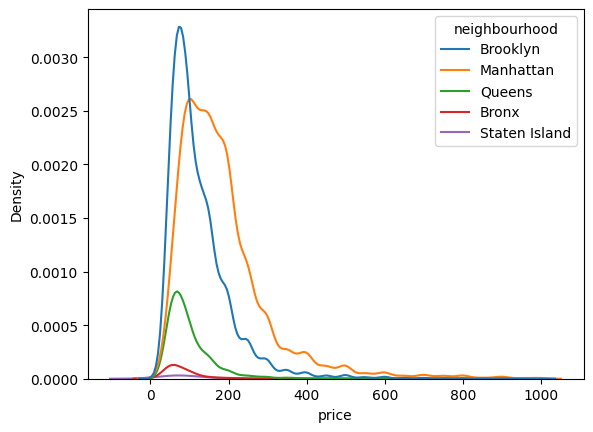

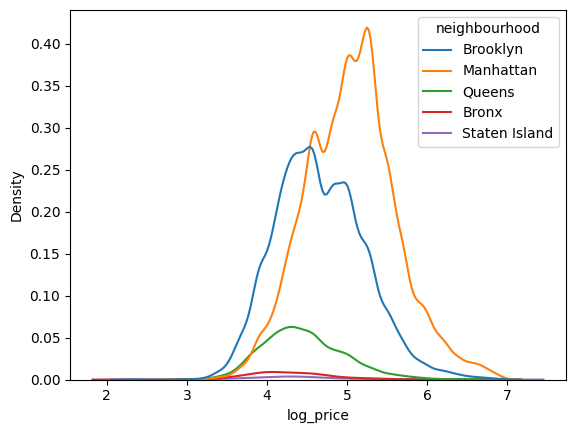

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     764.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:25:16   Log-Likelihood:            -1.8364e+05
No. Observations:               30297   AIC:                         3.673e+05
Df Residuals:                   30292   BIC:                         3.673e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

ValueError: Input contains NaN.

In [6]:


df = pd.read_csv('/content/data/airbnb_hw.csv', encoding='utf-8')

df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Price": "price",
    "Review Scores Rating": "rating",
    "Neighbourhood": "neighbourhood"
})

df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#KDP
sns.kdeplot(data=df, x="price", hue="neighbourhood")
plt.show()

df["log_price"] = np.log(df["price"])

sns.kdeplot(data=df, x="log_price", hue="neighbourhood")
plt.show()

import statsmodels.formula.api as smf
#regression of price on neigborhood
m1 = smf.ols("price ~ C(neighbourhood)", data=df).fit()
print(m1.summary())
#regression of price on rating

m2 = smf.ols("price ~ rating", data=df).fit()
print(m2.summary())


#regression of price + rating

m3 = smf.ols("price ~ C(neighbourhood) + rating", data=df).fit()
print(m3.summary())
#slopes for each neighborhoo

m4 = smf.ols("price ~ C(neighbourhood) * rating", data=df).fit()
print(m4.summary())

#cross validation
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

def cv_mse(formula, df, k=5):

    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    errors = []

    for train_idx, test_idx in kf.split(df):

        train = df.iloc[train_idx]
        test = df.iloc[test_idx]

        model = smf.ols(formula, data=train).fit()
        pred = model.predict(test)

        mse = mean_squared_error(test["price"], pred)
        errors.append(mse)

    return np.mean(errors)

mse2 = cv_mse("price ~ rating", df)
mse3 = cv_mse("price ~ C(neighbourhood) + rating", df)
mse4 = cv_mse("price ~ C(neighbourhood) * rating", df)

print(mse2, mse3, mse4)

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
